# 07 — Leave-One-Load-Out (LOLO) Visualization
### Mục 0.3 (phần 2) — Trực quan hóa cấu trúc kiểm định LOLO

**Mục đích**: trực quan hóa cấu trúc 4-fold LOLO (định nghĩa chính thức ở
mục 2.1 của đề cương) và kiểm tra độ cân bằng số file giữa các mức tải
trước khi dùng làm cấu trúc kiểm định chính thức cho toàn đề tài.

Hàm `generate_lolo_folds()` dùng ở đây được **import nguyên vẹn** từ
`common/splitting.py` — dùng lại y hệt ở Giai đoạn 1-2, không viết lại lần
thứ hai để tránh lệch cấu trúc giữa các giai đoạn.

**Giới hạn cần nhớ (mục 0.4 của đề cương)**: LOLO trên CWRU đo tổng quát
hóa qua **điều kiện tải**, không phải qua **vòng bi vật lý độc lập** — vì
CWRU dùng chung 1 vòng bi qua nhiều mức tải liên tiếp.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from common import pipeline, splitting
pd.set_option("display.max_colwidth", 120)

In [2]:
# ============================== CẤU HÌNH ==============================
# Đổi USE_SYNTHETIC_DATA = False và chỉnh REAL_DATA_ROOT khi đã có dữ liệu
# CWRU thật. Xem README.md phần "Chuyển sang dữ liệu thật".
USE_SYNTHETIC_DATA = True
REAL_DATA_ROOT = Path("../../data/raw")            # <-- de_tai_nckh/data/raw/
SYNTHETIC_DATA_ROOT = Path("./_data/synthetic_cwru")
OUTPUT_DIR = Path("./outputs")
FORCE_REBUILD_MANIFEST = False
# ========================================================================

In [3]:
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

> ⚠️ **Lưu ý dữ liệu giả lập**: khi `USE_SYNTHETIC_DATA = True`, mọi tín hiệu
> trong notebook này là **giả lập** (nhiễu + xung điều biên mô phỏng), chỉ để
> kiểm tra code chạy đúng và xem trước hình dạng đầu ra. **Không dùng số liệu
> giả lập này làm kết quả báo cáo chính thức.** Khi có dữ liệu CWRU thật, đổi
> `USE_SYNTHETIC_DATA = False` ở cell CẤU HÌNH và chạy lại toàn bộ notebook.

In [4]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 40


,file_path,load_hp,label,fault_diameter_mils,or_position,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning
0,_data/synthetic_cwru/0hp/B_007.mat,0,B,7.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
1,_data/synthetic_cwru/0hp/B_014.mat,0,B,14.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
2,_data/synthetic_cwru/0hp/B_021.mat,0,B,21.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
3,_data/synthetic_cwru/0hp/IR_007.mat,0,IR,7.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
4,_data/synthetic_cwru/0hp/IR_014.mat,0,IR,14.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False


## Cấu trúc 4 fold

In [5]:
folds = splitting.generate_lolo_folds(loads=(0, 1, 2, 3))
for fold in folds:
    print(f"Test = tải {{{fold['test_load']}}}  |  Train/Val = tải {fold['trainval_loads']}")

Test = tải {0}  |  Train/Val = tải [1, 2, 3]
Test = tải {1}  |  Train/Val = tải [0, 2, 3]
Test = tải {2}  |  Train/Val = tải [0, 1, 3]
Test = tải {3}  |  Train/Val = tải [0, 1, 2]


## Sơ đồ trực quan cấu trúc LOLO

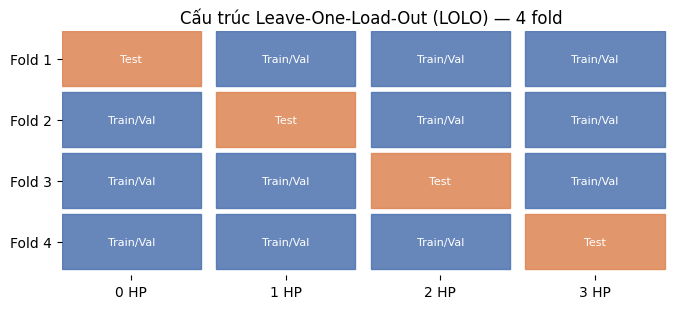

In [6]:
loads = [0, 1, 2, 3]
fig, ax = plt.subplots(figsize=(7, 3.2))

color_trainval = "#4C72B0"
color_test = "#DD8452"

for fold_idx, fold in enumerate(folds):
    for load in loads:
        is_test = (load == fold["test_load"])
        color = color_test if is_test else color_trainval
        ax.add_patch(plt.Rectangle((load, fold_idx), 0.9, 0.9, color=color, alpha=0.85))
        label = "Test" if is_test else "Train/Val"
        ax.text(load + 0.45, fold_idx + 0.45, label, ha="center", va="center",
                fontsize=8, color="white")

ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.set_xticks([l + 0.45 for l in loads])
ax.set_xticklabels([f"{l} HP" for l in loads])
ax.set_yticks([i + 0.45 for i in range(4)])
ax.set_yticklabels([f"Fold {i+1}" for i in range(4)])
ax.set_title("Cấu trúc Leave-One-Load-Out (LOLO) — 4 fold")
ax.invert_yaxis()
for spine in ax.spines.values():
    spine.set_visible(False)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_lolo_structure.png", dpi=150)
plt.show()

## Kiểm tra cân bằng số file giữa các mức tải (ảnh hưởng trực tiếp đến từng fold)

load_hp
0    10
1    10
2    10
3    10
Name: file_path, dtype: int64


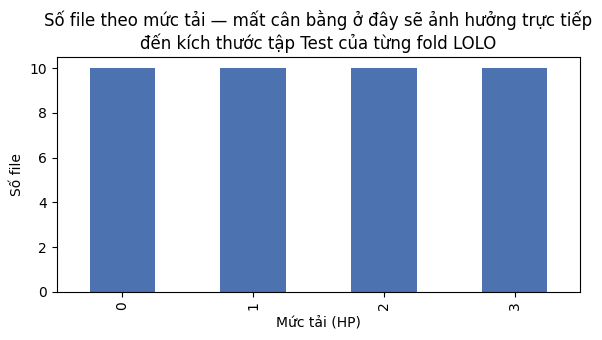


Tỉ lệ lệch lớn nhất giữa các tải: 1.00x
=> Tương đối cân bằng giữa các tải.


In [7]:
counts_by_load = manifest.groupby("load_hp")["file_path"].count()
print(counts_by_load)

fig, ax = plt.subplots(figsize=(6, 3.5))
counts_by_load.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_xlabel("Mức tải (HP)")
ax.set_ylabel("Số file")
ax.set_title("Số file theo mức tải — mất cân bằng ở đây sẽ ảnh hưởng trực tiếp\nđến kích thước tập Test của từng fold LOLO")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_file_count_by_load.png", dpi=150)
plt.show()

max_ratio = counts_by_load.max() / counts_by_load.min()
print(f"\nTỉ lệ lệch lớn nhất giữa các tải: {max_ratio:.2f}x")
if max_ratio > 1.5:
    print("=> Lệch đáng kể — cân nhắc ghi chú ảnh hưởng này khi phân tích "
          "kết quả từng fold ở Giai đoạn 2 (mục 2.1: fold nào thấp hơn hẳn "
          "cần được phân tích nguyên nhân).")
else:
    print("=> Tương đối cân bằng giữa các tải.")

## Ghi chú cho báo cáo

- Sơ đồ `07_lolo_structure.png` dùng trực tiếp minh họa mục 2.1 của báo cáo.
- Nếu số file lệch đáng kể giữa các tải, cần nêu rõ trong phần Thảo luận
  khi một fold LOLO cho kết quả thấp hơn hẳn các fold còn lại.
- Nhắc lại giới hạn LOLO trên CWRU (đã nêu ở mục 0.4/Phạm vi & giới hạn) —
  nên đặt ngay cạnh sơ đồ này trong báo cáo để người đọc không hiểu nhầm
  đây là kiểm định qua vòng bi độc lập.